In [ ]:
from pathlib import Path
import pandas as pd
import torch
import os

# Project root
BASE_DIR = Path("../data")

RAW_DATA_PATH = BASE_DIR / "raw"
PROCESSED_DATA_PATH = BASE_DIR / "processed"

Mounted at /content/drive


In [ ]:
df = pd.read_parquet(RAW_DATA_PATH / "training_sample_1M.parquet")
df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 19 columns):
 #   Column                  Non-Null Count    Dtype
---  ------                  --------------    -----
 0   userId                  1000000 non-null  object
 1   movieId                 1000000 non-null  object
 2   rating_x                1000000 non-null  float64
 3   movieYear               999860 non-null   int64
 4   movieURL                999860 non-null   object
 5   movieTitle              999860 non-null   object
 6   critic_score            998995 non-null   float64
 7   critic_sentiment        998995 non-null   object
 8   audience_score          999846 non-null   float64
 9   audience_sentiment      999846 non-null   object
 10  release_date_theaters   979333 non-null   object
 11  release_date_streaming  999860 non-null   object
 12  rating_y                986335 non-null   object
 13  original_language       999595 non-null   object
 14  runtime          

In [3]:
df.head()

,userId,movieId,rating_x,movieYear,movieURL,movieTitle,critic_score,critic_sentiment,audience_score,audience_sentiment,release_date_theaters,release_date_streaming,rating_y,original_language,runtime,critic_fresh_pct,critic_avg_sentiment,top_critic_ratio,critic_review_count
0,782587125,42c0dd81-a26d-351b-b446-385fdbdf4669,4.5,2004,https://www.rottentomatoes.com/m/shrek_2,Shrek 2,89.0,positive,69.0,positive,"Apr 12, 2024","Nov 25, 2015",PG (Some Crude Humor|A Brief Substance Referen...,English,1h 32m,0.887029,0.887029,0.251046,239
1,797056402,c8afce97-a899-3ba6-a919-a3a1e2608fba,5.0,1999,https://www.rottentomatoes.com/m/matrix,The Matrix,83.0,positive,85.0,positive,"Sep 19, 2024","Jan 1, 2009",R (Sci-Fi Violence|Brief Language),English,2h 16m,0.826087,0.826087,0.280193,207
2,795138838,eb68a512-22dc-3452-9c6d-c26568f7128f,3.5,1999,https://www.rottentomatoes.com/m/10_things_i_h...,10 Things I Hate About You,71.0,positive,69.0,positive,"Mar 31, 1999, Wide","Oct 2, 2014",PG-13,English,1h 37m,0.712766,0.712766,0.276596,94
3,790493343,164b8b2b-5d00-3774-b113-8a318489edee,2.5,2006,https://www.rottentomatoes.com/m/a_guide_to_re...,A Guide to Recognizing Your Saints,76.0,positive,73.0,positive,"Sep 29, 2006, Limited","May 22, 2017",R (Pervasive Language|Drug Use|Sexuality|Some ...,English,1h 44m,0.755319,0.755319,0.414894,94
4,786683315,00d1dd5b-5a41-3248-9080-3ef553dd9015,4.0,2004,https://www.rottentomatoes.com/m/notebook,The Notebook,54.0,negative,85.0,positive,"Jun 25, 2004, Wide","Mar 18, 2013",PG-13 (Some Sexuality),English,2h 4m,0.538462,0.538462,0.252747,182


In [4]:
# renaming `rating_x` as target rating and `rating_y` as movie rating
df = df.rename(columns={'rating_x': 'target_rating', 'rating_y': 'movie_rating'})

### Exploring data features

In [5]:
# Unique users in the dataset
unique_users = df['userId'].nunique()
print(f"Number of unique users: {unique_users}")

Number of unique users: 565657


In [6]:
# Unique movies in the dataset
unique_movies = df['movieId'].nunique()
print(f"Number of unique movies: {unique_movies}")

Number of unique movies: 8191


In [7]:
# rating_x
df['target_rating'].min()

# converting all rating < 1 to 1, so that the rating limit becomes 1-5
df['target_rating'] = df['target_rating'].apply(lambda x: 1 if x < 1 else x)

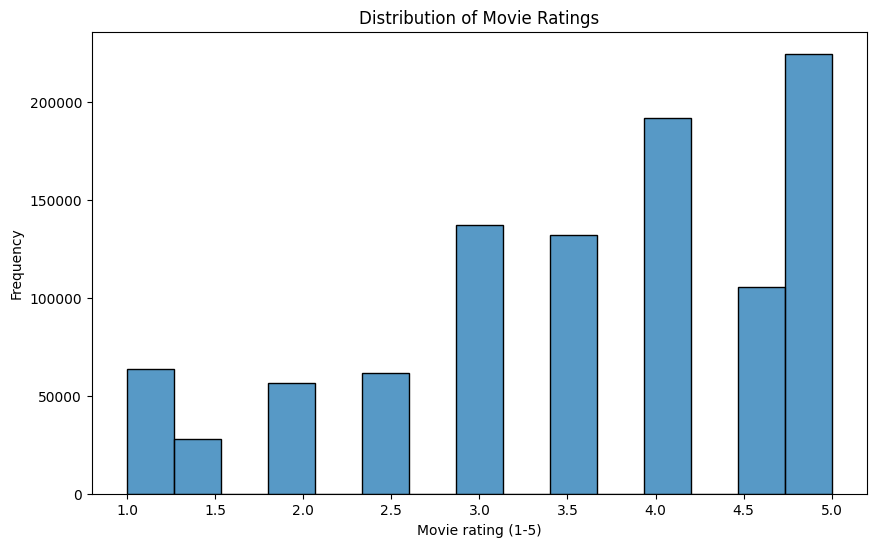

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['target_rating'], bins=15, kde=False)
plt.xlabel("Movie rating (1-5)")
plt.ylabel("Frequency")
plt.title("Distribution of Movie Ratings")
plt.show()

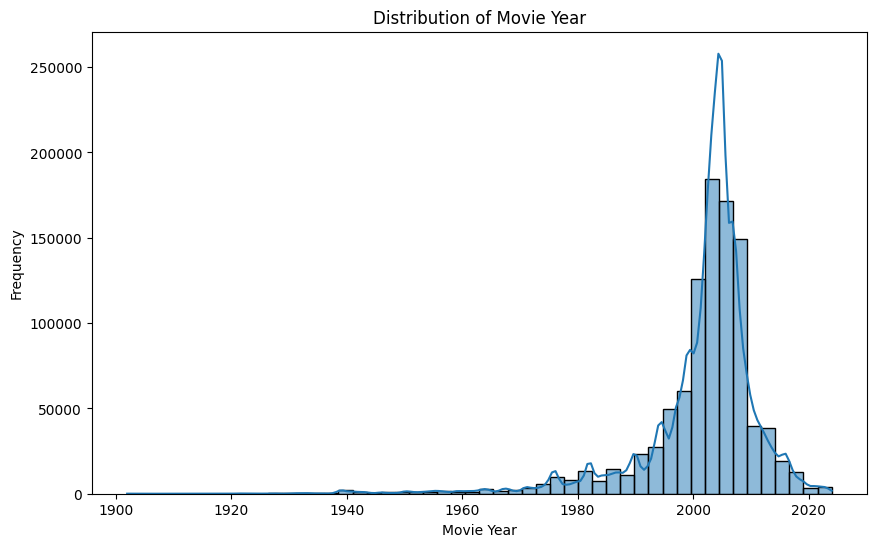

In [9]:
# movieYear
plt.figure(figsize=(10,6))
sns.histplot(df['movieYear'], bins=50, kde=True)
plt.xlabel("Movie Year")
plt.ylabel("Frequency")
plt.title("Distribution of Movie Year")
plt.show()

Even though the dataset contains movies from 1990-2024, the distribution of movie year is highly skewed as most of the movies in the dataset is modern (1980s and after).

In [10]:
# movie titles
df['movieTitle'].nunique()

7876

In [11]:
unique_movies

8191

In [12]:
# Group by movieTitle and count unique movieId
title_id_counts = df.groupby('movieTitle')['movieId'].nunique().sort_values(ascending=False)

# Filter for titles with more than 1 unique movieId
duplicate_titles = title_id_counts[title_id_counts > 1]

print(f"Number of titles with multiple movieIds: {len(duplicate_titles)}")
duplicate_titles.head(10)

Number of titles with multiple movieIds: 250


,movieId
movieTitle,
Beauty and the Beast,4
The Three Musketeers,4
Alice in Wonderland,3
All Quiet on the Western Front,3
Black Christmas,3
Cinderella,3
Godzilla,3
Halloween,3
Hamlet,3


In [13]:
# Get the list of titles with multiple IDs
dup_title_list = duplicate_titles.index.tolist()

# Filter the original dataframe for these titles
duplicate_title_df = df[df['movieTitle'].isin(dup_title_list)][['movieTitle', 'movieId', 'movieYear']]

# Drop duplicates to see unique combinations of Title, ID, and Year
unique_versions = duplicate_title_df.drop_duplicates().sort_values(['movieTitle', 'movieYear'])

# Display the first 20 rows
unique_versions.head(20)

,movieTitle,movieId,movieYear
1012,12 Angry Men,7b7f4c61-df44-3341-92a8-05e2a5392c83,1957
27510,12 Angry Men,a71522be-9561-3153-bc6e-2dec654a0c33,2017
185412,3:10 to Yuma,1137afaf-5f03-343b-b472-dac5368f3569,1957
1466,3:10 to Yuma,63e810b2-da9a-33d0-b8c8-956950495a66,2007
1183,A Nightmare on Elm Street,91d32967-95b4-300a-b00f-14eff0a33e8e,1984
3004,A Nightmare on Elm Street,b5612b3a-ba53-34ea-8896-b886211b65ab,2010
28107,A Star Is Born,63561207-9dd4-3432-8b13-9bad2884f5cc,1976
31258,A Star Is Born,a63be955-1d47-381f-b32b-04c2d32e44e1,2018
2498,Aladdin,23e7fde3-a4d5-338c-8783-f3de6f791fd6,1992
12138,Aladdin,f26f39dc-a8ac-38ae-b51e-b30f59a677fe,2019


We can see that there are several movies with the same name that were released in different years, thus they have the same name but unique movieId.

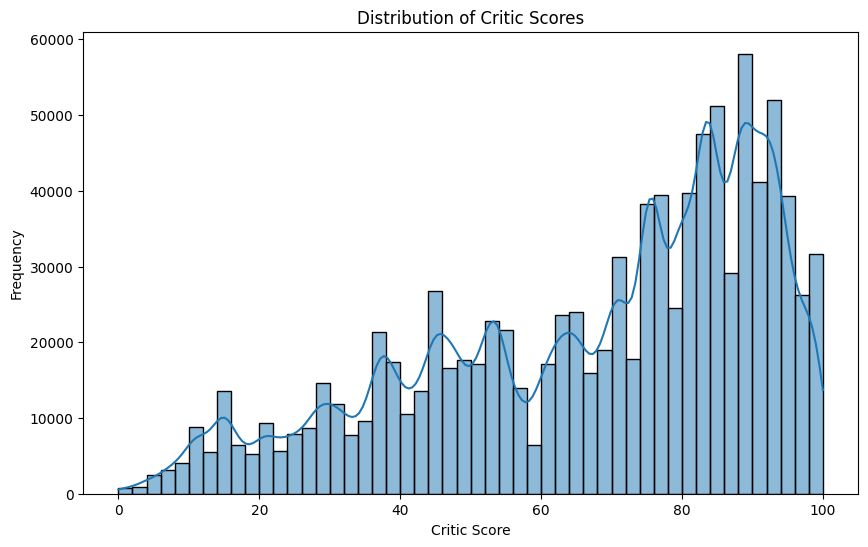

In [14]:
# critic score histogram
plt.figure(figsize=(10,6))
sns.histplot(df['critic_score'], bins=50, kde=True)
plt.xlabel("Critic Score")
plt.ylabel("Frequency")
plt.title("Distribution of Critic Scores")
plt.show()

In [15]:
# critic sentiment
df['critic_sentiment'].value_counts()

,count
critic_sentiment,
positive,666930
negative,332065


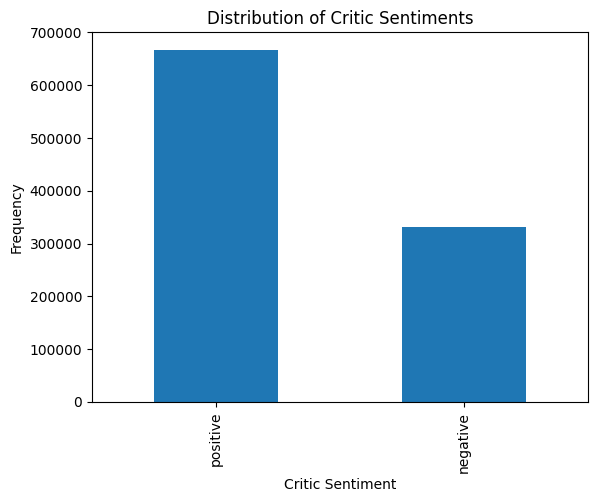

In [16]:

df['critic_sentiment'].value_counts().plot(kind='bar')
plt.xlabel("Critic Sentiment")
plt.ylabel("Frequency")
plt.title("Distribution of Critic Sentiments")
plt.show()

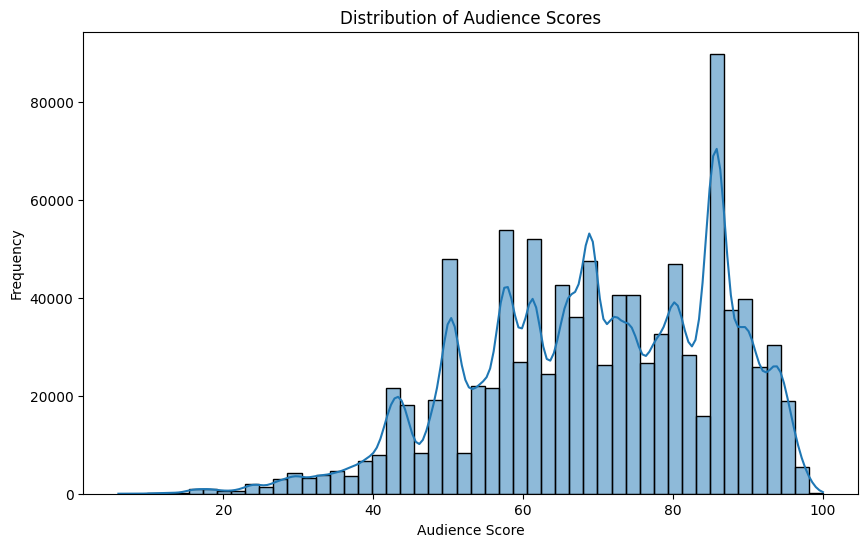

In [17]:
# audience score
plt.figure(figsize=(10,6))
sns.histplot(df['audience_score'], bins=50, kde=True)
plt.xlabel("Audience Score")
plt.ylabel("Frequency")
plt.title("Distribution of Audience Scores")
plt.show()


In [18]:
# audience sentiment
df['audience_sentiment'].value_counts()

,count
audience_sentiment,
positive,716216
negative,283630


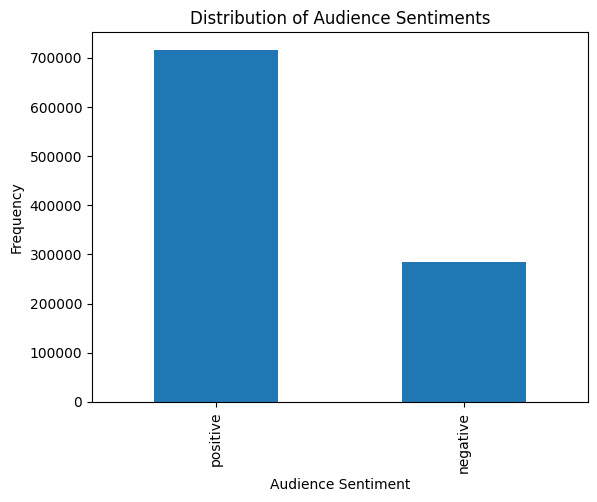

In [19]:
df['audience_sentiment'].value_counts().plot(kind='bar')
plt.xlabel("Audience Sentiment")
plt.ylabel("Frequency")
plt.title("Distribution of Audience Sentiments")
plt.show()

Audience sentiment and critic sentiment are very similar to each other, it would be better to remove one of them during modeling process.

In [20]:
# release dates
df = df.rename(columns={'release_date_theaters': 'release_date_theatres'})

In [21]:
# First of all we need to convert date from obj to datetime

df[df['release_date_theatres'].str.len() == df['release_date_theatres'].str.len().max()].head()

,userId,movieId,target_rating,movieYear,movieURL,movieTitle,critic_score,critic_sentiment,audience_score,audience_sentiment,release_date_theatres,release_date_streaming,movie_rating,original_language,runtime,critic_fresh_pct,critic_avg_sentiment,top_critic_ratio,critic_review_count
15,782421949,f67c28af-8622-3dd5-8939-56ce51a73ebd,5.0,1996.0,https://www.rottentomatoes.com/m/happy_gilmore,Happy Gilmore,62.0,positive,85.0,positive,"Feb 16, 1996, Original","Jun 15, 2012",PG-13,English,1h 32m,0.618182,0.618182,0.254545,55.0
41,781336409,2f0f70aa-9f71-3013-8b12-00e852862c40,4.0,1995.0,https://www.rottentomatoes.com/m/now_and_then,Now and Then,33.0,negative,82.0,positive,"Oct 20, 1995, Original","Aug 1, 2019",PG-13,English,1h 36m,0.333333,0.333333,0.333333,21.0
88,783724370,67f669a2-71f1-3abd-8e60-a4cb390c83d4,2.0,2006.0,https://www.rottentomatoes.com/m/ask_the_dust,Ask the Dust,35.0,negative,41.0,negative,"Mar 10, 2006, Original","Jun 15, 2011",R (Nudity|Language|Some Sexuality),English,1h 57m,0.349515,0.349515,0.388350,103.0
91,783493663,0b61d66f-bf61-3810-9a35-c9706fe4ff52,5.0,1995.0,https://www.rottentomatoes.com/m/seven,Seven,83.0,positive,95.0,positive,"Sep 22, 1995, Original","Jul 6, 2010",R,English,2h 5m,0.828767,0.828767,0.349315,146.0
92,789651751,282bcf47-09d7-31c6-8e73-941ef77d61a9,2.0,1996.0,https://www.rottentomatoes.com/m/the_nutty_pro...,The Nutty Professor,65.0,positive,44.0,negative,"Jun 28, 1996, Original","Jun 15, 2012",PG-13,English,1h 35m,0.649123,0.649123,0.315789,57.0


In [22]:
# we need to extract the date and month, year and remarks

import re

def extract_date_info_v2(date_str):
    if pd.isna(date_str):
        return None, None, None, None

    # Convert to string to be safe
    date_str = str(date_str).strip()

    # Pattern to match: Month Day, Year, Optional(Remarks)
    # It looks for Month (word), Day (digits), Year (digits), and optionally ", Remarks"
    # Examples: "Feb 16, 1996, Original" or "Apr 12, 2024"
    match = re.match(r'([A-Za-z]+)\s+(\d+),\s+(\d+)(?:,\s+(.*))?', date_str)

    if match:
        groups = match.groups()
        # groups will be (Month, Day, Year, Remarks) or (Month, Day, Year, None)
        return groups[0], groups[1], groups[2], groups[3]
    else:
        return None, None, None, None

# Re-apply the improved function
df[['theatres_month', 'theatres_day', 'theatres_year', 'theatres_remarks']] = df['release_date_theatres'].apply(lambda x: pd.Series(extract_date_info_v2(x)))

# Check the results again, including rows that failed before
df[['release_date_theatres', 'theatres_month', 'theatres_day', 'theatres_year', 'theatres_remarks']].head()

,release_date_theatres,theatres_month,theatres_day,theatres_year,theatres_remarks
0,"Apr 12, 2024",Apr,12,2024,None
1,"Sep 19, 2024",Sep,19,2024,None
2,"Mar 31, 1999, Wide",Mar,31,1999,Wide
3,"Sep 29, 2006, Limited",Sep,29,2006,Limited
4,"Jun 25, 2004, Wide",Jun,25,2004,Wide


In [23]:
df[['streaming_month', 'streaming_day', 'streaming_year', 'streaming_remarks']] = df['release_date_streaming'].apply(lambda x: pd.Series(extract_date_info_v2(x)))

df[['streaming_month', 'streaming_day', 'streaming_year']].head()

,streaming_month,streaming_day,streaming_year
0,Nov,25,2015
1,Jan,1,2009
2,Oct,2,2014
3,May,22,2017
4,Mar,18,2013


In [24]:
df = df.drop(columns=['streaming_remarks'])

In [25]:
df['theatres_remarks'].value_counts()

,count
theatres_remarks,
Wide,742173
Original,96349
Limited,30443


In [26]:
# convert multiple features to nullable int (Int64 handles NaNs)
df['theatres_day'] = pd.to_numeric(df['theatres_day'], errors='coerce').astype('Int64')
df['theatres_year'] = pd.to_numeric(df['theatres_year'], errors='coerce').astype('Int64')

df['streaming_day'] = pd.to_numeric(df['streaming_day'], errors='coerce').astype('Int64')
df['streaming_year'] = pd.to_numeric(df['streaming_year'], errors='coerce').astype('Int64')

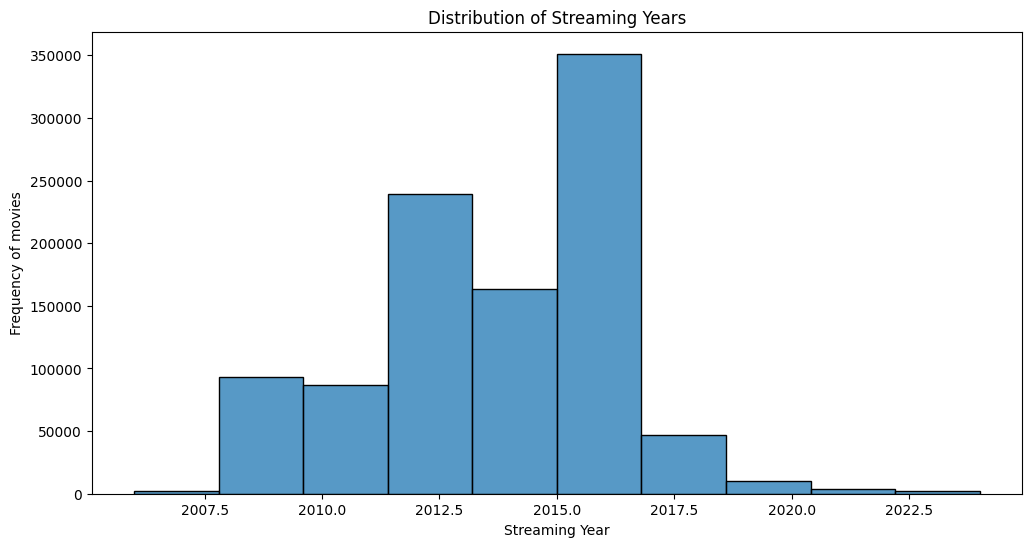

In [27]:
plt.figure(figsize=(12,6))
# Use bins=30 to see the yearly distribution better
sns.histplot(df['streaming_year'].dropna(), bins=10, kde=False)
plt.xlabel("Streaming Year")
plt.ylabel("Frequency of movies")
plt.title("Distribution of Streaming Years")
plt.show()

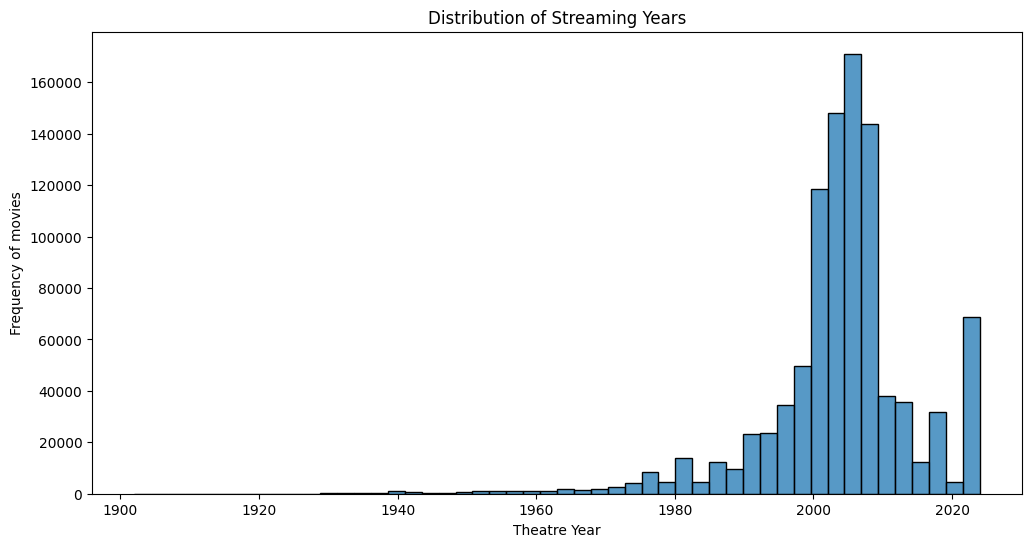

In [28]:
plt.figure(figsize=(12,6))
sns.histplot(df['theatres_year'].dropna(), bins=50, kde=False)
plt.xlabel("Theatre Year")
plt.ylabel("Frequency of movies")
plt.title("Distribution of Streaming Years")
plt.show()

Theatre year and movie year are identical cols, except for the movies that had limited release or re-released, so I think we should remove theatre year while modeling.

In [29]:
# movie rating
df['movie_rating'].value_counts()

,count
movie_rating,
R,59047
PG,56724
PG-13,51178
G,36811
PG-13 (Disaster Related Peril|Brief Language|Nudity|Sensuality|Violence),14013
...,...
R (Violence/Bloody Images|Sexual Content|Language),1
R (Violence|Sexuality/Nudity|Language),1
R (Violence|Some Drug Material|Pervasive Language),1


In [30]:
def get_clean_rating(rating):
    if pd.isna(rating):
        return None

    rating = str(rating).strip()

    # List of known ratings to check for at the start of the string
    # Order matters: check longer strings first to avoid partial matches (e.g. PG-13 vs PG)
    known_ratings = [
        'PG-13', 'NC-17', 'TV-MA', 'TV-14', 'TV-PG', 'TV-G', 'TV-Y7', 'TV-Y',
        'PG', 'R', 'G', 'NR', 'UR', 'Not Rated', 'Unrated'
    ]

    for r in known_ratings:
        # Check if the rating string starts with one of the known ratings
        # We also check if it's the exact string OR if it's followed by a non-alphanumeric character (like space or parenthesis)
        if rating.upper().startswith(r.upper()):
            return r

    return rating # Return original if no match found (or handle as 'Other')

# Apply the function
df['simple_rating'] = df['movie_rating'].apply(get_clean_rating)

# Check the results
df['simple_rating'].value_counts()

,count
simple_rating,
PG-13,458991
R,325550
PG,162525
G,36811
TV-G,919
NC-17,751
TV-14,386
TV-MA,228
TV-PG,174


In [31]:
# original language
df['original_language'].value_counts()

,count
original_language,
English,969105
English (United Kingdom),9981
Japanese,4081
Chinese,2609
French (France),2438
Spanish (Spain),1986
Italian,1029
German,994
Korean,898


In [32]:
def simplify_language(lang):
    if pd.isna(lang):
        return lang
    if lang in ['British English', 'English (United Kingdom)', 'English (Australia)', 'Australian English']:
        return 'English'
    elif lang in ['French (France)', 'French (Canada)', 'Canadian French']:
        return 'French'
    elif lang in ['Spanish (Spain)', 'European Spanish']:
        return 'Spanish'
    elif lang in ['Portuguese (Brazil)']:
        return 'Portuguese'
    else:
        return lang

df['original_language'] = df['original_language'].apply(simplify_language)
df['original_language'].value_counts()

,count
original_language,
English,979669
Japanese,4081
French,3614
Spanish,2617
Chinese,2609
Italian,1029
German,994
Korean,898
Swedish,645


In [33]:
language_counts = df['original_language'].value_counts(normalize=True) * 100
print("Top 10 Languages by Percentage:")
print(language_counts.head(10))

Top 10 Languages by Percentage:
original_language
English             98.006593
Japanese             0.408265
French               0.361546
Spanish              0.261806
Chinese              0.261006
Italian              0.102942
German               0.099440
Korean               0.089836
Swedish              0.064526
Unknown language     0.053122
Name: proportion, dtype: float64


In [34]:
threshold = 0.1
common_languages = language_counts[language_counts > threshold].index

# Use vectorized isin instead of apply for performance
df['is_common_language'] = df['original_language'].isin(common_languages).astype(int)

print(f"Common languages (>{threshold}%): {list(common_languages.to_pandas()) if hasattr(common_languages, 'to_pandas') else list(common_languages)}")

# Aggregate counts first
is_common_counts = df['is_common_language'].value_counts()
print(is_common_counts)


Common languages (>0.1%): ['English', 'Japanese', 'French', 'Spanish', 'Chinese', 'Italian']
is_common_language
1    993619
0      6381
Name: count, dtype: int64


In [35]:
import re

def parse_runtime(runtime_str):
    if pd.isna(runtime_str):
        return None

    runtime_str = str(runtime_str).lower()
    hours = 0
    minutes = 0

    # Extract hours
    h_match = re.search(r'(\d+)h', runtime_str)
    if h_match:
        hours = int(h_match.group(1))

    # Extract minutes
    m_match = re.search(r'(\d+)m', runtime_str)
    if m_match:
        minutes = int(m_match.group(1))

    return hours * 60 + minutes

# Apply the function to create a new column
df['runtime_minutes'] = df['runtime'].apply(parse_runtime).astype('Int64')

# Display the original and converted values to verify
print(df[['runtime', 'runtime_minutes']].head(10))
print("\nSummary statistics for runtime_minutes:")
print(df['runtime_minutes'].describe())

  runtime  runtime_minutes
0  1h 32m               92
1  2h 16m              136
2  1h 37m               97
3  1h 44m              104
4   2h 4m              124
5  1h 36m               96
6  1h 55m              115
7   2h 2m              122
8  1h 59m              119
9  1h 37m               97

Summary statistics for runtime_minutes:
count      999851.0
mean     117.573034
std       27.665792
min            12.0
25%            98.0
50%           113.0
75%           126.0
max           317.0
Name: runtime_minutes, dtype: Float64


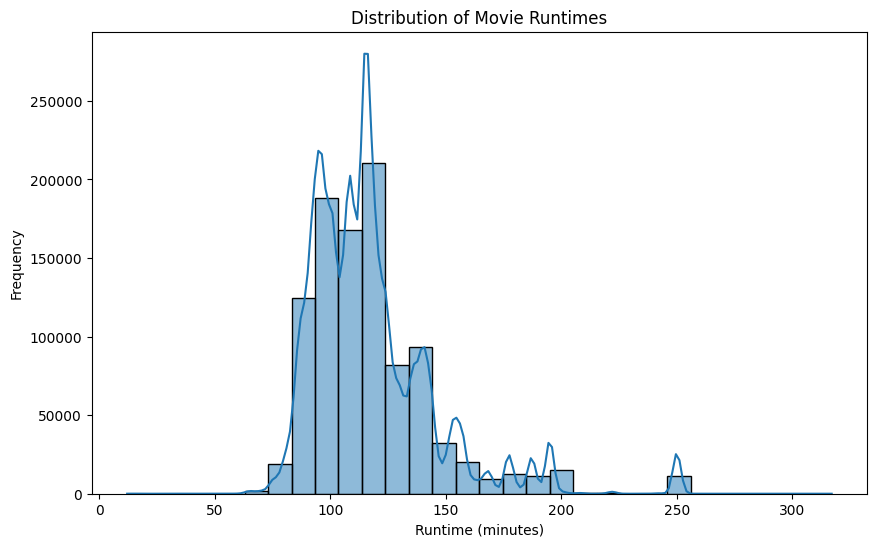

In [36]:
plt.figure(figsize=(10,6))
# The environment uses %load_ext cudf.pandas, so df is a proxy object.
# Seaborn might struggle with the proxy object directly if it tries to access internal attributes.
# Converting to numpy array is a robust way to pass data to plotting libraries.
sns.histplot(df['runtime_minutes'].dropna().to_numpy(), bins=30, kde=True)
plt.xlabel("Runtime (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Movie Runtimes")
plt.show()

In [37]:
df.head()

,userId,movieId,target_rating,movieYear,movieURL,movieTitle,critic_score,critic_sentiment,audience_score,audience_sentiment,...,theatres_month,theatres_day,theatres_year,theatres_remarks,streaming_month,streaming_day,streaming_year,simple_rating,is_common_language,runtime_minutes
0,782587125,42c0dd81-a26d-351b-b446-385fdbdf4669,4.5,2004.0,https://www.rottentomatoes.com/m/shrek_2,Shrek 2,89.0,positive,69.0,positive,...,Apr,12,2024,None,Nov,25,2015,PG,1,92
1,797056402,c8afce97-a899-3ba6-a919-a3a1e2608fba,5.0,1999.0,https://www.rottentomatoes.com/m/matrix,The Matrix,83.0,positive,85.0,positive,...,Sep,19,2024,None,Jan,1,2009,R,1,136
2,795138838,eb68a512-22dc-3452-9c6d-c26568f7128f,3.5,1999.0,https://www.rottentomatoes.com/m/10_things_i_h...,10 Things I Hate About You,71.0,positive,69.0,positive,...,Mar,31,1999,Wide,Oct,2,2014,PG-13,1,97
3,790493343,164b8b2b-5d00-3774-b113-8a318489edee,2.5,2006.0,https://www.rottentomatoes.com/m/a_guide_to_re...,A Guide to Recognizing Your Saints,76.0,positive,73.0,positive,...,Sep,29,2006,Limited,May,22,2017,R,1,104
4,786683315,00d1dd5b-5a41-3248-9080-3ef553dd9015,4.0,2004.0,https://www.rottentomatoes.com/m/notebook,The Notebook,54.0,negative,85.0,positive,...,Jun,25,2004,Wide,Mar,18,2013,PG-13,1,124


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 29 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   userId                  1000000 non-null  object 
 1   movieId                 1000000 non-null  object 
 2   target_rating           1000000 non-null  float64
 3   movieYear               999860 non-null   float64
 4   movieURL                999860 non-null   object 
 5   movieTitle              999860 non-null   object 
 6   critic_score            998995 non-null   float64
 7   critic_sentiment        998995 non-null   object 
 8   audience_score          999846 non-null   float64
 9   audience_sentiment      999846 non-null   object 
 10  release_date_theatres   979333 non-null   object 
 11  release_date_streaming  999860 non-null   object 
 12  movie_rating            986335 non-null   object 
 13  original_language       999595 non-null   object 
 14  run

In [39]:
# we need to remove some of these features before training models
cols_to_remove = [
    'movieURL',
    'movieTitle',
    'audience_sentiment',
    'release_date_theatres',
    'release_date_streaming',
    'runtime',
    'critic_fresh_pct',
    'theatres_year',
    'movie_rating',
    'critic_avg_sentiment',
    'theatres_remarks'
]

new_df = df.drop(columns=cols_to_remove)
new_df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 18 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   userId               1000000 non-null  object
 1   movieId              1000000 non-null  object
 2   target_rating        1000000 non-null  float64
 3   movieYear            999860 non-null   float64
 4   critic_score         998995 non-null   float64
 5   critic_sentiment     998995 non-null   object
 6   audience_score       999846 non-null   float64
 7   original_language    999595 non-null   object
 8   top_critic_ratio     999860 non-null   float64
 9   critic_review_count  999860 non-null   float64
 10  theatres_month       979333 non-null   object
 11  theatres_day         979333 non-null   Int64
 12  streaming_month      999860 non-null   object
 13  streaming_day        999860 non-null   Int64
 14  streaming_year       999860 non-null   Int64
 15  simple_rating

In [40]:
new_df.head()

,userId,movieId,target_rating,movieYear,critic_score,critic_sentiment,audience_score,original_language,top_critic_ratio,critic_review_count,theatres_month,theatres_day,streaming_month,streaming_day,streaming_year,simple_rating,is_common_language,runtime_minutes
0,782587125,42c0dd81-a26d-351b-b446-385fdbdf4669,4.5,2004.0,89.0,positive,69.0,English,0.251046,239.0,Apr,12,Nov,25,2015,PG,1,92
1,797056402,c8afce97-a899-3ba6-a919-a3a1e2608fba,5.0,1999.0,83.0,positive,85.0,English,0.280193,207.0,Sep,19,Jan,1,2009,R,1,136
2,795138838,eb68a512-22dc-3452-9c6d-c26568f7128f,3.5,1999.0,71.0,positive,69.0,English,0.276596,94.0,Mar,31,Oct,2,2014,PG-13,1,97
3,790493343,164b8b2b-5d00-3774-b113-8a318489edee,2.5,2006.0,76.0,positive,73.0,English,0.414894,94.0,Sep,29,May,22,2017,R,1,104
4,786683315,00d1dd5b-5a41-3248-9080-3ef553dd9015,4.0,2004.0,54.0,negative,85.0,English,0.252747,182.0,Jun,25,Mar,18,2013,PG-13,1,124


In [ ]:
new_df.to_parquet(PROCESSED_DATA_PATH + "ready_to_train_1M.parquet")